# Análise Exploratória — Medical Abstracts TC Corpus

Objetivo: entender a distribuição das categorias originais do dataset, o
comportamento da rotulagem heurística de urgência
(`ml.labeling.assign_urgency_label`) e características do texto (tamanho,
vocabulário) que informam os hiperparâmetros do pipeline TF-IDF + Random
Forest (ver `ml/train.py`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.labeling import assign_urgency_label

sns.set_theme(style="whitegrid")

RAW_DIR = Path.cwd().parent / "data" / "raw"

In [2]:
train_df = pd.read_csv(RAW_DIR / "medical_tc_train.csv")
labels_df = pd.read_csv(RAW_DIR / "medical_tc_labels.csv")

train_df.shape, labels_df

((11550, 2),
    condition_label                   condition_name
 0                1                        neoplasms
 1                2        digestive system diseases
 2                3          nervous system diseases
 3                4          cardiovascular diseases
 4                5  general pathological conditions)

## Distribuição das categorias originais (`condition_label`)

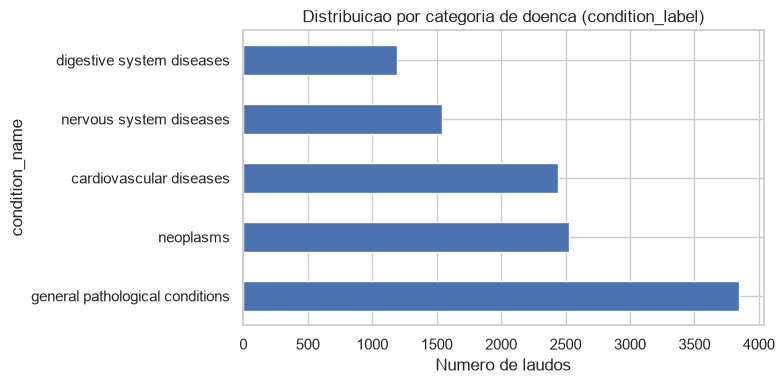

condition_name
general pathological conditions    3844
neoplasms                          2530
cardiovascular diseases            2441
nervous system diseases            1540
digestive system diseases          1195
Name: count, dtype: int64

In [3]:
condition_counts = (
    train_df.merge(labels_df, on="condition_label")["condition_name"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(8, 4))
condition_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Numero de laudos")
ax.set_title("Distribuicao por categoria de doenca (condition_label)")
plt.tight_layout()
plt.show()

condition_counts

## Rótulo de urgência derivado (heurística por palavras-chave)

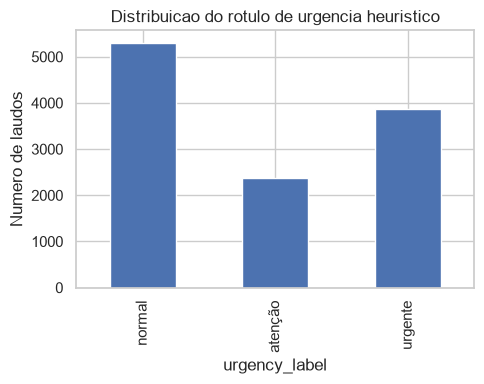

urgency_label
normal     5304
urgente    3879
atenção    2367
Name: count, dtype: int64

In [4]:
train_df["urgency_label"] = train_df["medical_abstract"].apply(assign_urgency_label)
urgency_counts = train_df["urgency_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
urgency_counts.reindex(["normal", "atenção", "urgente"]).plot(kind="bar", ax=ax)
ax.set_ylabel("Numero de laudos")
ax.set_title("Distribuicao do rotulo de urgencia heuristico")
plt.tight_layout()
plt.show()

urgency_counts

## Tamanho dos textos (número de palavras)

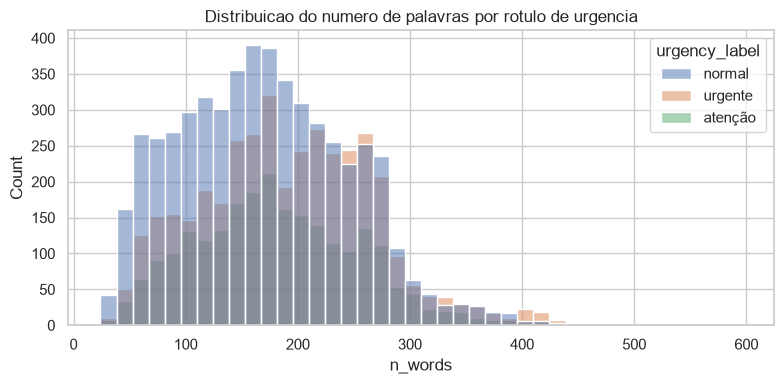

,count,mean,std,min,25%,50%,75%,max
urgency_label,,,,,,,,
atenção,2367.0,182.159696,73.442854,31.0,129.0,176.0,231.0,471.0
normal,5304.0,170.463801,76.273493,24.0,111.0,166.0,224.0,596.0
urgente,3879.0,190.651457,76.698439,30.0,137.0,190.0,245.0,453.0


In [5]:
train_df["n_words"] = train_df["medical_abstract"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=train_df, x="n_words", hue="urgency_label", bins=40, ax=ax)
ax.set_title("Distribuicao do numero de palavras por rotulo de urgencia")
plt.tight_layout()
plt.show()

train_df.groupby("urgency_label")["n_words"].describe()

## Palavras mais frequentes por classe de urgência

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

for label in ["normal", "atenção", "urgente"]:
    subset = train_df.loc[train_df["urgency_label"] == label, "medical_abstract"]
    vectorizer = CountVectorizer(stop_words="english", max_features=15)
    counts = vectorizer.fit_transform(subset)
    top_words = pd.Series(
        counts.sum(axis=0).A1, index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)
    print(f"\nTop palavras — {label}:")
    print(top_words)


Top palavras — normal:
patients     9869
disease      2376
group        2031
treatment    1992
cells        1906
study        1865
cell         1855
blood        1683
cancer       1682
tumor        1629
results      1546
cases        1494
patient      1412
10           1392
clinical     1376
dtype: int64



Top palavras — atenção:
patients         6601
disease          1445
chronic          1193
treatment        1152
group            1013
study             936
patient           862
years             837
normal            830
complications     801
blood             799
cases             772
therapy           739
results           729
associated        726
dtype: int64



Top palavras — urgente:
patients      10994
acute          2728
disease        2100
group          2025
treatment      1770
patient        1633
study          1624
coronary       1419
severe         1412
years          1387
clinical       1378
cases          1345
myocardial     1288
blood          1224
infarction     1217
dtype: int64


## Conclusões

- O dataset original é razoavelmente distribuído entre as 5 categorias de
  doença (`condition_label`), cada uma com centenas a milhares de laudos
  (ver gráfico acima).
- A rotulagem heurística de urgência produz classes de tamanhos
  diferentes entre si (ver contagem acima) — por isso `build_pipeline()`
  usa `class_weight="balanced"` no `RandomForestClassifier`, para não
  enviesar a classificação em favor da classe majoritária.
- O comprimento médio dos abstracts (em palavras) é similar entre as três
  classes de urgência, o que sugere que o sinal preditivo vem do
  vocabulário (presença das palavras-chave da heurística e termos
  correlacionados), não do tamanho do texto — reforça a escolha de TF-IDF
  com `max_features=5000` como representação suficiente para um modelo
  "leve".
- As palavras mais frequentes por classe (célula acima) devem incluir
  visivelmente termos da própria lista de palavras-chave da heurística
  (`ml/labeling.py`) — validação visual de que a rotulagem está de fato
  capturando o sinal pretendido, e não ruído.